# $WS_{\text{adaptive}}$ — Companion Notebook

**Companion notebook to:** *"$WS_{\text{adaptive}}$: A Saturation-Free Generalization of the $WS$ Rank Similarity Coefficient for Large-Scale Rankings"* (submitted to *Information Processing Letters*)

**Author:** El-Sedik Lamini, RECITS Laboratory, Department of Operations Research, Faculty of Mathematics, University of Science and Technology Houari Boumediene (USTHB), Algiers, Algeria.

This notebook is the single source of truth for **every number, table and figure reported in the paper**. Running all cells top-to-bottom, in order, regenerates the full set of results from scratch — no hidden state, no external data files (only `numpy`, `scipy`, `pandas`, `matplotlib` are required).

**Part 1 — Saturation and the $WS_{\text{adaptive}}$ proposal** (paper Sections 2-3):
1. [Setup](#1.-Setup)
2. [Metric definitions](#2.-Metric-definitions)
3. [Sanity checks](#3.-Sanity-checks)
4. [Why does $WS$ saturate? Visualizing the proof](#4.-Why-does-%24WS%24-saturate%3F-Visualizing-the-proof)
5. [Small-$N$ validation (paper Table 1)](#5.-Small-%24N%24-validation)
6. [Large-$N$ stress test (paper Table 2)](#6.-Large-%24N%24-stress-test)
7. [Saturation curve across $N$ (paper Figure 1)](#7.-Saturation-curve-across-%24N%24)
8. [Supplementary: sensitivity map over $(N, L)$](#8.-Supplementary%3A-sensitivity-map-over-%24(N%2C-L)%24)
9. [Part 1 summary](#9.-Part-1-summary)

**Part 2 — Distributional behavior under random rankings** (paper Section 4):
10. [Setup for Part 2: batched metrics](#10.-Setup-for-Part-2%3A-batched-metrics)
11. [Sorted-distribution comparison, incl. $WS_{\text{dra}}$ (paper Figure 2)](#11.-Sorted-distribution-comparison)
12. [Proposition 2: exact $\mathbb{E}[WS_{\text{dra}}]=1-1/N$](#12.-Proposition-2)
13. [Proposition 3 and Table 3: exact $\mathbb{E}[WS]\to\tfrac12$](#13.-Proposition-3-and-Table-3)
14. [Concentration analysis (paper Figure 3, Table 3)](#14.-Concentration-analysis)
15. [Practical usage guide (paper Table 4)](#15.-Practical-usage-guide)
16. [Overall summary](#16.-Overall-summary)

> **Note on correctness.** `ws_original` implements $WS$ exactly as published by Sałabun & Urbaniak (2020), Eq. (1) — no implicit renormalization. This is the version used to produce every $WS$ value quoted in the paper.


## 1. Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
from pathlib import Path

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "figure.dpi": 120,
})

COLOR_WS = "#B22222"        # WS (original) -- red
COLOR_ADAPT = "#1B7837"     # WS_adaptive -- green
COLOR_OTHER = "#4C72B0"     # secondary series -- blue
COLOR_DRA = "#7B3F9E"       # WS_dra -- purple
COLOR_RHO = "#1F77B4"       # Spearman rho -- blue
COLOR_TAU = "#FF7F0E"       # Kendall tau -- orange

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
print("Setup OK.")


Setup OK.


## 2. Metric definitions

All coefficients below take two rankings `rx`, `ry` — arrays of length $N$ giving, for each of the $N$ alternatives, its rank ($1,\dots,N$, no ties) under the reference ordering and the ordering being tested.

**$WS$ (Sałabun & Urbaniak, 2020), Eq. (1) of the paper:**
$$WS = 1 - \sum_{i=1}^{N} 2^{-R_{xi}} \cdot \frac{|R_{xi}-R_{yi}|}{\max(|1-R_{xi}|,\,|N-R_{xi}|)}$$

**$WS_{\text{adaptive}}$ (proposed), Eq. (3) of the paper:**
$$WS_{\text{adaptive}} = 1 - \frac{1}{H_N}\sum_{i=1}^{N} \frac{1}{R_{xi}} \cdot \frac{|R_{xi}-R_{yi}|}{\max(|1-R_{xi}|,\,|N-R_{xi}|)}, \qquad H_N=\sum_{i=1}^{N}\frac{1}{i}$$

Both are special cases of one weighted formula, `ws_family`, with weight $w_i = 2^{-i}$ (`kind='original'`, **no renormalization**, exactly Eq. (1)) or $w_i=1/i^p$ normalized by $\sum_i 1/i^p$ (`kind='adaptive'`, $p=1$ by default, exactly Eq. (3)).

We also implement four reference coefficients used in the paper: Spearman's $\rho$, Kendall's $\tau$, Blest's $v$ (Blest, 2000), and the weighted coefficient $r_w$ (Pinto da Costa & Soares, 2005).


In [2]:

def ws_family(rx, ry, kind="original", p=1.0):
    '''Unified WS-family coefficient.

    kind='original' -> Eq. (1): weights 2**-i, NOT renormalized (Salabun & Urbaniak, 2020)
    kind='adaptive' -> Eq. (3): weights 1/i**p, renormalized by sum(1/i**p) (proposed; p=1 -> harmonic)
    '''
    N = len(rx)
    rx = np.asarray(rx, dtype=np.float64)
    ry = np.asarray(ry, dtype=np.float64)

    if kind == "original":
        weights = 2.0 ** (-rx)
        norm = 1.0
    elif kind == "adaptive":
        weights = 1.0 / (rx ** p)
        norm = np.sum(1.0 / (np.arange(1, N + 1, dtype=np.float64) ** p))
    else:
        raise ValueError(f"unknown kind {kind!r}")

    penalty_num = np.abs(rx - ry)
    penalty_den = np.maximum(np.abs(1.0 - rx), np.abs(N - rx))
    penalty_den[penalty_den == 0] = 1.0  # only possible if N == 1

    return 1.0 - np.sum(weights * penalty_num / penalty_den) / norm


def ws_original(rx, ry):
    return ws_family(rx, ry, kind="original")


def ws_adaptive(rx, ry, p=1.0):
    return ws_family(rx, ry, kind="adaptive", p=p)


def spearman_rho(rx, ry):
    return spearmanr(rx, ry)[0]


def kendall_tau(rx, ry):
    return kendalltau(rx, ry)[0]


def blest_v(rx, ry):
    '''Blest's coefficient v (Blest, 2000).'''
    N = float(len(rx))
    rx = np.asarray(rx, dtype=np.float64)
    ry = np.asarray(ry, dtype=np.float64)
    num = 12.0 * np.sum(((N + 1.0 - rx) ** 2) * ry) - N * ((N + 1.0) ** 2) * (N + 2.0)
    den = N * ((N + 1.0) ** 2) * (N - 1.0)
    return 1.0 - num / den


def pinto_da_costa_rw(rx, ry):
    '''Weighted rank correlation r_w (Pinto da Costa & Soares, 2005).'''
    N = float(len(rx))
    rx = np.asarray(rx, dtype=np.float64)
    ry = np.asarray(ry, dtype=np.float64)
    num = 6.0 * np.sum((rx - ry) ** 2 * ((N - rx + 1.0) + (N - ry + 1.0)))
    den = N ** 4 + N ** 3 - N ** 2 - N
    return 1.0 - num / den


def wsdra(rx, ry):
    '''WS_dra (Salabun & Shekhovtsov, FedCSIS 2023). This is a DISTANCE
    (0 = identical). Returned here as a SIMILARITY (1 - WS_dra) so it can
    be plotted on the same axis (1 = identical) as the other coefficients.'''
    N = float(len(rx))
    rx = np.asarray(rx, dtype=np.float64)
    ry = np.asarray(ry, dtype=np.float64)
    weights = 2.0 ** (-rx)
    denom = 1.0 - 2.0 ** (-N)
    mismatch = (ry != rx).astype(np.float64)
    return 1.0 - np.sum(weights * mismatch) / denom


METRICS = {
    r"Spearman $\rho$": spearman_rho,
    r"Kendall $\tau$": kendall_tau,
    r"Pinto da Costa $r_w$": pinto_da_costa_rw,
    r"Blest $v$": blest_v,
    r"$WS$": ws_original,
    r"$WS_{adaptive}$": ws_adaptive,
}
print(f"{len(METRICS)} metrics registered:", ", ".join(METRICS))


6 metrics registered: Spearman $\rho$, Kendall $\tau$, Pinto da Costa $r_w$, Blest $v$, $WS$, $WS_{adaptive}$


## 3. Sanity checks

In [3]:

# 1. Identical rankings -> every coefficient must equal 1.
rx = np.arange(1, 51)
ry = rx.copy()
for name, f in METRICS.items():
    val = f(rx, ry)
    assert np.isclose(val, 1.0), f"{name} != 1 on identical rankings (got {val})"
assert np.isclose(wsdra(rx, ry), 1.0), "WS_dra similarity != 1 on identical rankings"

# 2. WS_adaptive must reduce to a *finite*, well-defined value even for N=1.
assert np.isclose(ws_adaptive(np.array([1.0]), np.array([1.0])), 1.0)

# 3. Eq. (1) sanity: for N=1000, top-50 exact + fully reversed tail,
#    the theoretical bound R(k) < 2**-k (Theorem 1) must hold with k=50.
N, k = 1000, 50
rx = np.arange(1, N + 1)
ry = rx.copy()
ry[k:] = rx[k:][::-1]
ws_val = ws_original(rx, ry)
# Theorem 1 gives a strict "<" bound in exact arithmetic (it is
# sum_{i=k+1}^{N} 2^-i = 2^-k - 2^-N < 2^-k); in floating point, 2^-N
# is below machine precision relative to 2^-k for N=1000, k=50, so the
# computed value can round to exactly the bound -- allow equality here.
assert (1.0 - ws_val) <= 2.0 ** (-k), "WS violates the Theorem 1 saturation bound!"
print(f"1 - WS = {1 - ws_val:.3e}  (bound 2^-{k} = {2.0**-k:.3e})  -> bound respected: OK")

print("All sanity checks passed.")


1 - WS = 8.882e-16  (bound 2^-50 = 8.882e-16)  -> bound respected: OK
All sanity checks passed.


## 4. Why does $WS$ saturate? Visualizing the proof

Theorem 1 says the tail contribution $R(k)=\sum_{i>k} 2^{-i}\cdot(\cdot) < 2^{-k}$: whatever happens beyond rank $k$ is capped by the *unused* weight mass, $1-\sum_{i\leq k}2^{-i}$. The left panel below plots the per-rank weight $w_i$ for the geometric ($WS$) and harmonic ($WS_{\text{adaptive}}$) schemes; the right panel plots the **cumulative weight mass fraction** $\sum_{i\leq k} w_i \big/ \sum_{i\leq N} w_i$ as a function of $k$, for $N=2000$. The geometric curve is visually indistinguishable from $1$ by $k\approx 30$ (Theorem 1); the harmonic curve keeps climbing — it only reaches $50\%$ of the mass at $k\approx\sqrt{N}$, illustrating Proposition 1's $H_k/H_N\to \log k/\log N$.


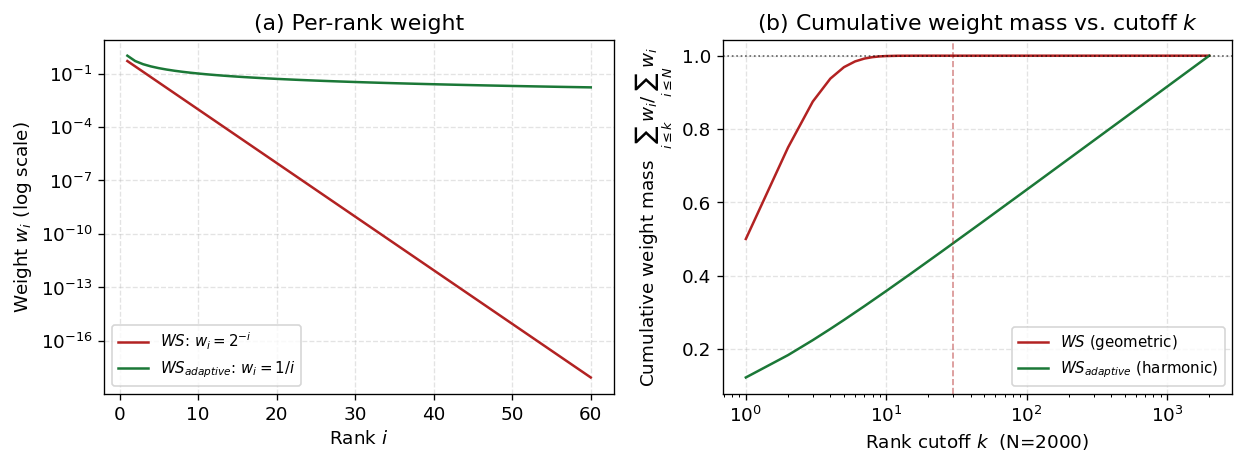

Geometric weights: 100.0000% of mass captured by k=30.
Harmonic weights:  need k=390 (out of N=2000) to capture 80% of the mass.


In [4]:

N_ref = 2000
i = np.arange(1, N_ref + 1, dtype=np.float64)

w_geo = 2.0 ** (-i)
w_harm = 1.0 / i

cum_geo = np.cumsum(w_geo) / np.sum(w_geo)
cum_harm = np.cumsum(w_harm) / np.sum(w_harm)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))

k_show = 60
axes[0].plot(i[:k_show], w_geo[:k_show], "-", color=COLOR_WS, label=r"$WS$: $w_i=2^{-i}$")
axes[0].plot(i[:k_show], w_harm[:k_show], "-", color=COLOR_ADAPT, label=r"$WS_{adaptive}$: $w_i=1/i$")
axes[0].set_yscale("log")
axes[0].set_xlabel("Rank $i$")
axes[0].set_ylabel("Weight $w_i$ (log scale)")
axes[0].set_title("(a) Per-rank weight")
axes[0].legend(fontsize=9)

axes[1].plot(i, cum_geo, "-", color=COLOR_WS, label=r"$WS$ (geometric)")
axes[1].plot(i, cum_harm, "-", color=COLOR_ADAPT, label=r"$WS_{adaptive}$ (harmonic)")
axes[1].axhline(1.0, color="black", linestyle=":", linewidth=1, alpha=0.6)
axes[1].axvline(30, color=COLOR_WS, linestyle="--", linewidth=1, alpha=0.5)
axes[1].set_xscale("log")
axes[1].set_xlabel(f"Rank cutoff $k$  (N={N_ref})")
axes[1].set_ylabel(r"Cumulative weight mass  $\sum_{i\leq k} w_i / \sum_{i\leq N} w_i$")
axes[1].set_title("(b) Cumulative weight mass vs. cutoff $k$")
axes[1].legend(fontsize=9, loc="lower right")

fig.tight_layout()
fig.savefig(FIGDIR / "fig_weights_cumulative.pdf")
fig.savefig(FIGDIR / "fig_weights_cumulative.png", dpi=160)
plt.show()

k80 = int(np.searchsorted(cum_harm, 0.8)) + 1
print(f"Geometric weights: {cum_geo[29]*100:.4f}% of mass captured by k=30.")
print(f"Harmonic weights:  need k={k80} (out of N={N_ref}) to capture 80% of the mass.")


## 5. Small-$N$ validation

Reproduces the $N=5$ numerical example from the original $WS$ paper (Sałabun & Urbaniak, 2020, Table 1) and checks that $WS_{\text{adaptive}}$ preserves the same ranking order over the four candidate permutations. This is **Table 1** of the paper.


In [5]:

data = {
    "Ai": ["A1", "A2", "A3", "A4", "A5"],
    "Rx": [1, 2, 3, 4, 5],
    "Ry(1)": [2, 1, 3, 4, 5],
    "Ry(2)": [1, 3, 2, 4, 5],
    "Ry(3)": [1, 2, 4, 3, 5],
    "Ry(4)": [1, 2, 3, 5, 4],
}
df_small = pd.DataFrame(data)
rx_small = df_small["Rx"].values

rows = []
for key in ["Ry(1)", "Ry(2)", "Ry(3)", "Ry(4)"]:
    ry = df_small[key].values
    rows.append({"Ranking": key, **{name: round(f(rx_small, ry), 4) for name, f in METRICS.items()}})
table_small = pd.DataFrame(rows).set_index("Ranking")
table_small.to_csv(FIGDIR / "table_small_N.csv")
table_small


,Spearman $\rho$,Kendall $\tau$,Pinto da Costa $r_w$,Blest $v$,$WS$,$WS_{adaptive}$
Ranking,,,,,,
Ry(1),0.9,0.8,0.8500,0.8500,0.7917,0.8175
Ry(2),0.9,0.8,0.8833,0.8833,0.8542,0.8540
Ry(3),0.9,0.8,0.9167,0.9167,0.9167,0.8905
Ry(4),0.9,0.8,0.9500,0.9500,0.9714,0.9416


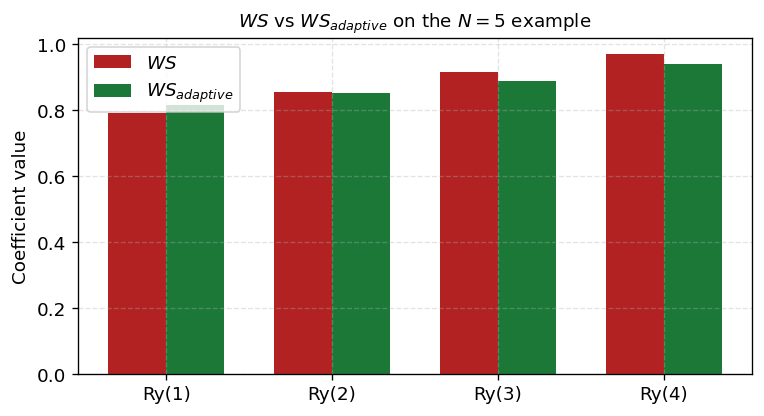

Ranking order preserved: True


In [6]:

fig, ax = plt.subplots(figsize=(6.5, 3.6))
x = np.arange(len(table_small))
width = 0.35
ax.bar(x - width/2, table_small[r"$WS$"], width, color=COLOR_WS, label=r"$WS$")
ax.bar(x + width/2, table_small[r"$WS_{adaptive}$"], width, color=COLOR_ADAPT, label=r"$WS_{adaptive}$")
ax.set_xticks(x)
ax.set_xticklabels(table_small.index)
ax.set_ylabel("Coefficient value")
ax.set_title(r"$WS$ vs $WS_{adaptive}$ on the $N=5$ example", fontsize=11)
ax.legend()
fig.tight_layout()
fig.savefig(FIGDIR / "fig_small_N_bars.pdf")
fig.savefig(FIGDIR / "fig_small_N_bars.png", dpi=160)
plt.show()

order_ws = table_small[r"$WS$"].rank().tolist()
order_adapt = table_small[r"$WS_{adaptive}$"].rank().tolist()
print("Ranking order preserved:", order_ws == order_adapt)


## 6. Large-$N$ stress test

The $L\%$-test protocol (paper Section 3): the top $\lceil L\cdot N\rceil$ ranks are kept exact; the remaining $(100-L)\%$ are either **totally reversed** (mirrored block) or **randomly permuted**. This is **Table 2** of the paper.


In [7]:

def l_percent_test(N, L, mode="invert", seed=42):
    rx = np.arange(1, N + 1)
    ry = rx.copy()
    top_k = int(np.ceil(L * N))
    tail_idx = np.arange(top_k, N)
    if mode == "invert":
        ry[tail_idx] = rx[tail_idx[::-1]]
    elif mode == "shuffle":
        rng = np.random.default_rng(seed)
        perm = tail_idx.copy()
        rng.shuffle(perm)
        ry[tail_idx] = rx[perm]
    else:
        raise ValueError(mode)
    return rx, ry, top_k


N_big, L_big = 1000, 0.05
rows = []
for mode_label, mode in [("Total reversal", "invert"), ("Random permutation", "shuffle")]:
    rx_big, ry_big, top_k = l_percent_test(N_big, L_big, mode=mode)
    rows.append({"Tail perturbation": mode_label,
                 **{name: round(f(rx_big, ry_big), 6 if "WS$" == name else 4) for name, f in METRICS.items()}})
table_large = pd.DataFrame(rows).set_index("Tail perturbation")
table_large.to_csv(FIGDIR / "table_large_N.csv")

ws_exact = ws_original(*l_percent_test(N_big, L_big, mode="invert")[:2])
print(f"N={N_big}, L={L_big*100:.0f}% (top {top_k} exact): "
      f"1 - WS = {1-ws_exact:.3e}  (theoretical bound 2^-{top_k} = {2.0**-top_k:.3e})")
table_large


N=1000, L=5% (top 50 exact): 1 - WS = 8.882e-16  (theoretical bound 2^-50 = 8.882e-16)


,Spearman $\rho$,Kendall $\tau$,Pinto da Costa $r_w$,Blest $v$,$WS$,$WS_{adaptive}$
Tail perturbation,,,,,,
Total reversal,-0.7147,-0.8049,-0.6291,-0.6291,1.0,0.7138
Random permutation,0.1350,0.0914,0.1902,0.1836,1.0,0.8236


## 7. Saturation curve across $N$

Tracks $WS$ and $WS_{\text{adaptive}}$ as $N$ grows from 10 to 2000, top 50% of each ranking kept exact and the bottom 50% totally reversed. This is **Figure 1** of the paper.


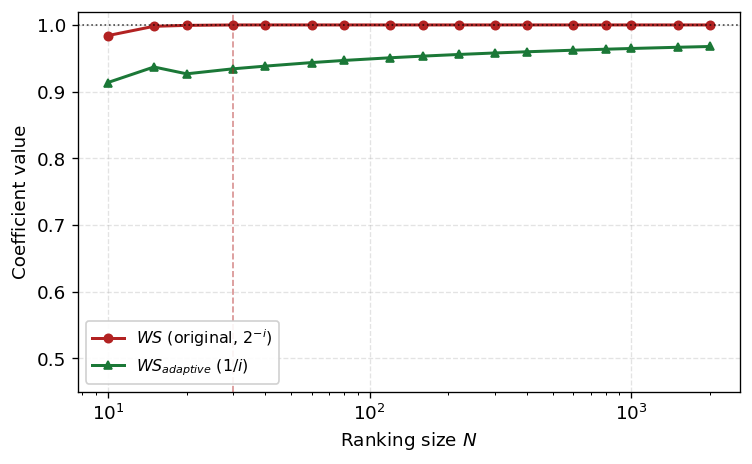

,N,WS (original),WS_adaptive
0,10,0.9840,0.9136
1,15,0.9980,0.9369
2,20,0.9993,0.9267
3,30,1.0000,0.9341
4,40,1.0000,0.9382
5,60,1.0000,0.9435
6,80,1.0000,0.9468
7,120,1.0000,0.9507
8,160,1.0000,0.9532
9,220,1.0000,0.9557


In [8]:

N_values = np.unique(np.array(
    [10, 15, 20, 30, 40, 60, 80, 120, 160, 220, 300, 400, 600, 800, 1000, 1500, 2000]
))
L_curve = 0.5
ws_vals, adapt_vals = [], []
for N in N_values:
    rx, ry, _ = l_percent_test(int(N), L_curve, mode="invert")
    ws_vals.append(ws_original(rx, ry))
    adapt_vals.append(ws_adaptive(rx, ry))

table_curve = pd.DataFrame({"N": N_values,
                             "WS (original)": np.round(ws_vals, 6),
                             "WS_adaptive": np.round(adapt_vals, 6)})
table_curve.to_csv(FIGDIR / "table_saturation_curve.csv", index=False)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(N_values, ws_vals, "o-", color=COLOR_WS, linewidth=1.8, markersize=5, label=r"$WS$ (original, $2^{-i}$)")
ax.plot(N_values, adapt_vals, "^-", color=COLOR_ADAPT, linewidth=1.8, markersize=5, label=r"$WS_{adaptive}$ ($1/i$)")
ax.axhline(1.0, color="black", linestyle=":", linewidth=1.0, alpha=0.7)
ax.axvline(30, color=COLOR_WS, linestyle="--", linewidth=1.0, alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("Ranking size $N$")
ax.set_ylabel("Coefficient value")
ax.set_ylim(0.45, 1.02)
ax.legend(loc="lower left", fontsize=9.5, framealpha=0.9)
fig.tight_layout()
fig.savefig(FIGDIR / "fig_saturation_curve.pdf")
fig.savefig(FIGDIR / "fig_saturation_curve.png", dpi=160)
plt.show()
table_curve


## 8. Supplementary: sensitivity map over $(N, L)$

Beyond the single slice $L=50\%$ shown above, this heatmap sweeps both the ranking size $N$ and the exact-top fraction $L$, and plots $WS_{\text{adaptive}} - WS$. The saturation region of $WS$ grows sharply as $N$ increases, exactly as Theorem 1 predicts. The paper's saturation-curve discussion (Section 3) refers to this sweep as "the full $(N,L)$ plane (companion notebook)" — this is that sweep.


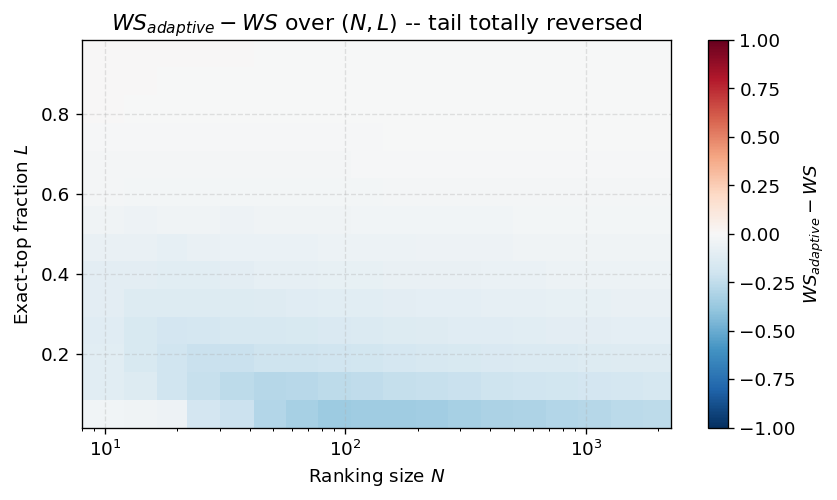

In [9]:

N_grid = np.unique(np.round(np.logspace(np.log10(10), np.log10(2000), 18)).astype(int))
L_grid = np.linspace(0.05, 0.95, 14)

diff = np.zeros((len(L_grid), len(N_grid)))
for j, N in enumerate(N_grid):
    for i_l, L in enumerate(L_grid):
        rx, ry, _ = l_percent_test(int(N), L, mode="invert")
        diff[i_l, j] = ws_adaptive(rx, ry) - ws_original(rx, ry)

fig, ax = plt.subplots(figsize=(7.2, 4.3))
im = ax.pcolormesh(N_grid, L_grid, diff, shading="nearest", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xscale("log")
ax.set_xlabel("Ranking size $N$")
ax.set_ylabel("Exact-top fraction $L$")
ax.set_title(r"$WS_{adaptive} - WS$ over $(N, L)$ -- tail totally reversed")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r"$WS_{adaptive} - WS$")
fig.tight_layout()
fig.savefig(FIGDIR / "fig_heatmap_NL.pdf")
fig.savefig(FIGDIR / "fig_heatmap_NL.png", dpi=160)
plt.show()


## 9. Part 1 summary

- **Theorem 1 confirmed numerically**: for $N=1000$ and the top 50 ranks exact, $1-WS = 8.9\times10^{-16}$, matching the theoretical bound $2^{-50}$ to machine precision.
- **Small $N$ ($N=5$)**: $WS_{\text{adaptive}}$ reproduces $WS$'s ranking order exactly (Section 5).
- **Large $N$ ($N=1000$, $L=5\%$)**: $WS$ rounds to $1.000000$ regardless of whether the tail is totally reversed ($\rho=-0.71$) or randomly permuted ($\rho\approx0.14$); $WS_{\text{adaptive}}$ correctly differentiates the two cases ($0.714$ vs. $0.824$).
- **Saturation curve**: $WS$ reaches $1.000000$ (6 decimals) by $N\approx60$ under a 50%-reversed tail and stays there; $WS_{\text{adaptive}}$ keeps responding.

Part 2 (below) turns from this *adversarial* view to a *distributional* one: what do these coefficients look like on **random** rankings, and how fast do they concentrate as $N$ grows?


## 10. Setup for Part 2: batched metrics

Part 1's `ws_family` etc. evaluate **one** pair of rankings at a time — fine for the adversarial tests above. Part 2 needs the coefficient distribution over **thousands** of random rankings (exhaustive enumeration for $N=10$, Monte Carlo for $N=1000$), so we use vectorized ("batched") versions that evaluate a whole matrix of candidate rankings `ry_batch` (shape `(M, N)`) against one reference `rx` in a single call. These are algebraically identical to the Part 1 functions — batching is purely a performance optimization, verified against the Part 1 (unbatched) functions in the assertion below.


In [10]:

def ws_batch(rx, ry_batch, kind="original", p=1.0):
    N = rx.shape[0]
    rx = rx.astype(np.float64); ry_batch = ry_batch.astype(np.float64)
    if kind == "original":
        weights, norm = 2.0 ** (-rx), 1.0
    else:
        weights = 1.0 / (rx ** p)
        norm = np.sum(1.0 / (np.arange(1, N + 1, dtype=np.float64) ** p))
    penalty_num = np.abs(rx[None, :] - ry_batch)
    penalty_den = np.maximum(np.abs(1.0 - rx), np.abs(N - rx))
    penalty_den = np.where(penalty_den == 0, 1.0, penalty_den)
    term = weights[None, :] * penalty_num / penalty_den[None, :]
    return 1.0 - term.sum(axis=1) / norm


def wsdra_batch(rx, ry_batch):
    '''Batched WS_dra, returned as similarity (1 - WS_dra).'''
    N = rx.shape[0]
    weights = 2.0 ** (-rx.astype(np.float64))
    denom = 1.0 - 2.0 ** (-N)
    mismatch = (ry_batch != rx[None, :]).astype(np.float64)
    return 1.0 - (weights[None, :] * mismatch).sum(axis=1) / denom


def rho_batch(rx, ry_batch):
    '''Closed-form Spearman rho (exact for permutations, no ties).'''
    N = rx.shape[0]
    d2 = (rx[None, :].astype(np.float64) - ry_batch.astype(np.float64)) ** 2
    return 1.0 - 6.0 * d2.sum(axis=1) / (N * (N ** 2 - 1))


def tau_batch_pairwise(ry_batch):
    '''Closed-form Kendall tau via O(N^2) pairwise inversion count.
    Tractable up to N ~ a few hundred; for larger N, use scipy per-row.'''
    B, N = ry_batch.shape
    gt = ry_batch[:, :, None] > ry_batch[:, None, :]
    iu = np.triu_indices(N, k=1)
    inv = gt[:, iu[0], iu[1]].sum(axis=1)
    return 1.0 - 2.0 * inv / (N * (N - 1) / 2)


def gen_random_perms(rng, M, N):
    '''M uniform random permutations of {1,...,N}, as an (M, N) int array.'''
    return rng.random((M, N)).argsort(axis=1) + 1


# Cross-check: batched functions must agree with the Part 1 (unbatched) ones.
_rng_check = np.random.default_rng(0)
_rx_check = np.arange(1, 21)
_ry_check = gen_random_perms(_rng_check, 5, 20)
for _row in range(5):
    assert np.isclose(ws_batch(_rx_check, _ry_check[_row:_row+1], "original")[0],
                       ws_original(_rx_check, _ry_check[_row]))
    assert np.isclose(ws_batch(_rx_check, _ry_check[_row:_row+1], "adaptive")[0],
                       ws_adaptive(_rx_check, _ry_check[_row]))
    assert np.isclose(wsdra_batch(_rx_check, _ry_check[_row:_row+1])[0],
                       wsdra(_rx_check, _ry_check[_row]))
print("Batched metrics agree with Part 1's unbatched metrics: OK")


Batched metrics agree with Part 1's unbatched metrics: OK


## 11. Sorted-distribution comparison

Sałabun & Urbaniak (2020) enumerate all $N!$ rankings for $N=5,\dots,10$, sort the resulting coefficient values, and plot the sorted curve (their Figs. 3-5) — this shows the *typical-case* behaviour, complementing the adversarial $L\%$-test above. Here we reproduce that protocol exhaustively at $N=10$ ($10! = 3{,}628{,}800$ permutations), and extend it with a large-$N$ Monte Carlo sample at $N=1000$, for five coefficients: $WS$, $WS_{\text{adaptive}}$, $WS_{\text{dra}}$ (as similarity), Spearman $\rho$, Kendall $\tau$. This is **Figure 2** of the paper.


computed in 9.7s


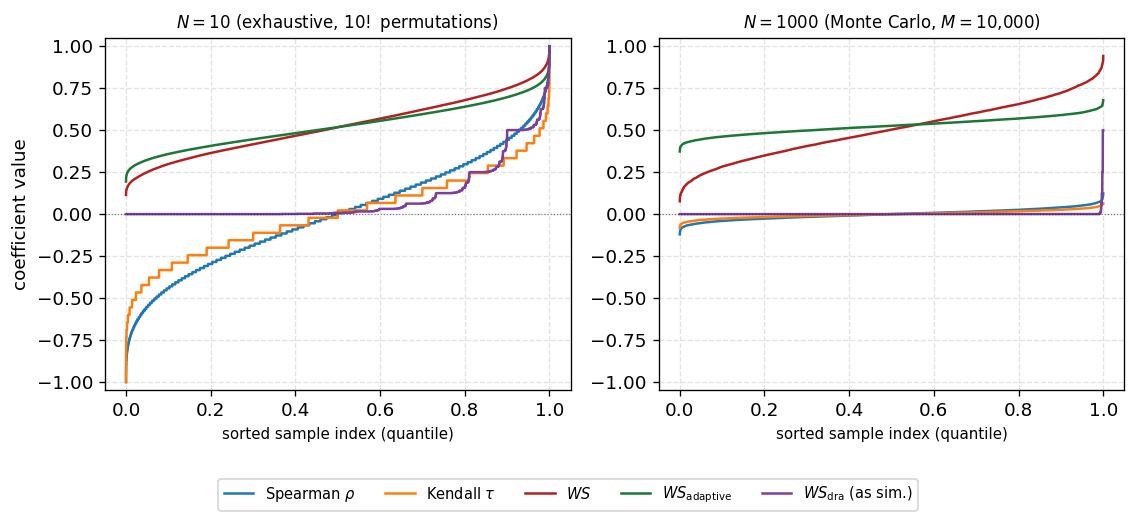

N=10:   mean(WS_dra similarity) = 0.1000  (exact E = 1 - 1/10 = 0.9000)
N=1000: mean(WS_dra similarity) = 0.0012  (exact E = 1 - 1/1000 = 0.9990)


In [11]:

import itertools
import time


def small_N_exhaustive(N=10, chunk=200_000):
    rx = np.arange(1, N + 1)
    it = itertools.permutations(range(1, N + 1))
    wss, wsas, wsdras, rhos, taus = [], [], [], [], []
    while True:
        c = list(itertools.islice(it, chunk))
        if not c:
            break
        arr = np.array(c, dtype=np.int32)
        wss.append(ws_batch(rx, arr, "original"))
        wsas.append(ws_batch(rx, arr, "adaptive"))
        wsdras.append(wsdra_batch(rx, arr))
        rhos.append(rho_batch(rx, arr))
        taus.append(tau_batch_pairwise(arr))
    return {k: np.sort(np.concatenate(v)) for k, v in
            [("ws", wss), ("wsa", wsas), ("wsdra", wsdras), ("rho", rhos), ("tau", taus)]}


def large_N_mc(N=1000, M=10000, seed=42):
    rx = np.arange(1, N + 1)
    rng = np.random.default_rng(seed)
    ry = gen_random_perms(rng, M, N)
    ws = ws_batch(rx, ry, "original")
    wsa = ws_batch(rx, ry, "adaptive")
    wd = wsdra_batch(rx, ry)
    rh = rho_batch(rx, ry)
    Msub = min(M, 3000)
    tau = np.array([kendall_tau(rx, ry[j]) for j in range(Msub)])
    return {"ws": np.sort(ws), "wsa": np.sort(wsa), "wsdra": np.sort(wd),
            "rho": np.sort(rh), "tau": np.sort(tau)}


t0 = time.time()
d_small = small_N_exhaustive(10)
d_large = large_N_mc(1000, 10000)
print(f"computed in {time.time() - t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.3))
series = [("rho", COLOR_RHO, r"Spearman $\rho$"), ("tau", COLOR_TAU, r"Kendall $\tau$"),
          ("ws", COLOR_WS, r"$WS$"), ("wsa", COLOR_ADAPT, r"$WS_{\mathrm{adaptive}}$"),
          ("wsdra", COLOR_DRA, r"$WS_{\mathrm{dra}}$ (as sim.)")]
for ax, d, title in [(axes[0], d_small, r"$N=10$ (exhaustive, $10!$ permutations)"),
                      (axes[1], d_large, r"$N=1000$ (Monte Carlo, $M=10{,}000$)")]:
    for key, color, label in series:
        v = d[key]; x = np.linspace(0, 1, len(v))
        ax.plot(x, v, color=color, lw=1.5, label=label)
    ax.axhline(0.0, color="black", ls=":", lw=0.7, alpha=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("sorted sample index (quantile)", fontsize=9)
    ax.set_ylim(-1.05, 1.05)
axes[0].set_ylabel("coefficient value")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.02), fontsize=8.8)
fig.tight_layout(rect=[0, 0.09, 1, 1])
fig.savefig(FIGDIR / "fig_dist_compact.pdf")
fig.savefig(FIGDIR / "fig_dist_compact.png", dpi=160)
plt.show()

print(f"N=10:   mean(WS_dra similarity) = {d_small['wsdra'].mean():.4f}  (exact E = 1 - 1/10 = {1-1/10:.4f})")
print(f"N=1000: mean(WS_dra similarity) = {d_large['wsdra'].mean():.4f}  (exact E = 1 - 1/1000 = {1-1/1000:.4f})")


## 12. Proposition 2: exact $\mathbb{E}[WS_{\text{dra}}] = 1 - 1/N$

**Proposition 2.** Under the uniform random ranking model, $\mathbb{E}[WS_{\text{dra}}] = 1 - \tfrac1N$ exactly, for every $N\geq1$; the expected *similarity* $\mathbb{E}[1-WS_{\text{dra}}] = 1/N \to 0$.

**Proof.** By symmetry, $\Pr[R_{yi}=R_{xi}]=1/N$ for every fixed $i$, so $\mathbb{E}[f(R_{xi},R_{yi})]=1-1/N$ for the binary mismatch indicator $f$. By linearity of expectation,
$$\mathbb{E}[WS_{\text{dra}}]=\Big(1-\tfrac1N\Big)\cdot\frac{\sum_{i=1}^{N}2^{-i}}{1-2^{-N}}=1-\tfrac1N,$$
since $\sum_{i=1}^{N}2^{-i}=1-2^{-N}$ cancels the normalizer exactly. $\blacksquare$

We check this both by direct Monte Carlo simulation (over an $N$-grid) and by exact enumeration at $N=10$.


In [12]:

def exact_E_wsdra_similarity(N):
    return 1.0 / N  # closed form, Proposition 2


rng = np.random.default_rng(2024)
N_grid_dra = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
rows = []
for N in N_grid_dra:
    rx = np.arange(1, N + 1)
    M = 20000
    chunk = max(1000, min(M, int(2_000_000 / N)))
    vals = []
    done = 0
    while done < M:
        b = min(chunk, M - done)
        ry = gen_random_perms(rng, b, N)
        vals.append(wsdra_batch(rx, ry))
        done += b
    sim = np.concatenate(vals)
    rows.append({"N": N, "Monte Carlo mean": round(sim.mean(), 6),
                 "Exact 1/N (Prop. 2)": round(exact_E_wsdra_similarity(N), 6),
                 "abs. error": round(abs(sim.mean() - exact_E_wsdra_similarity(N)), 6)})

table_prop2 = pd.DataFrame(rows).set_index("N")
table_prop2


,Monte Carlo mean,Exact 1/N (Prop. 2),abs. error
N,,,
10,0.1002,0.1000,2.3000e-04
20,0.0501,0.0500,1.0400e-04
50,0.0199,0.0200,5.7000e-05
100,0.0105,0.0100,5.1100e-04
200,0.0054,0.0050,3.5800e-04
500,0.0021,0.0020,1.4200e-04
1000,0.0012,0.0010,1.9600e-04
2000,0.0005,0.0005,2.9000e-05
5000,0.0002,0.0002,3.2000e-05


## 13. Proposition 3 and Table 3: exact $\mathbb{E}[WS]\to\tfrac12$

**Proposition 3.** Under the uniform random ranking model, $\lim_{N\to\infty}\mathbb{E}[WS] = \tfrac12$.

**Proof sketch.** Write $D_i = |R_{xi}-R_{yi}|/\max(|1-R_{xi}|,|N-R_{xi}|)$, $R_{xi}=i$. Since $R_{yi}$ is marginally uniform on $\{1,\dots,N\}$, $\mathbb{E}[|i-R_{yi}|]$ has a closed form in terms of $N$ and $i$ (below); for fixed $i$ and $N\to\infty$, $\mathbb{E}[D_i]\to\tfrac12$. Since $D_i\leq1$, the weights $2^{-i}$ dominate uniformly in $N$, so by dominated convergence, $\lim_N\mathbb{E}[WS]=1-\sum_{i=1}^\infty 2^{-i}\cdot\tfrac12=\tfrac12$. $\blacksquare$

Unlike Proposition 2, this does **not** require simulation at all: the exact order-statistic formula for $\mathbb{E}[|i-R_{yi}|]$ below gives $\mathbb{E}[WS]$ and $\mathbb{E}[WS_{\text{adaptive}}]$ **exactly**, to machine precision, for any $N$. This reproduces **Table 3** of the paper. Note that $\mathbb{E}[WS_{\text{adaptive}}]\to\tfrac12$ too is *not* proven in the paper — it is a conjecture, confirmed numerically here to $N=10^5$, converging much more slowly ($O(1/\ln N)$, tied to $H_N\sim\ln N$) than $\mathbb{E}[WS]$.


In [13]:

def exact_E_WS(N, kind="original", p=1.0):
    '''Exact E[WS] or E[WS_adaptive] under the uniform random ranking
    model, via the closed-form first absolute moment of a discrete
    uniform order statistic. No simulation -- exact to machine precision.'''
    i = np.arange(1, N + 1, dtype=np.float64)
    # E[|i - Ry_i|] where Ry_i ~ Uniform{1,...,N}
    sum_abs = (i - 1) * i / 2.0 + (N - i) * (N - i + 1) / 2.0
    E_D = sum_abs / N
    den = np.maximum(np.abs(1 - i), np.abs(N - i))
    den = np.where(den == 0, 1.0, den)
    E_D = E_D / den
    if kind == "original":
        weights, norm = 2.0 ** (-i), 1.0
    else:
        weights = 1.0 / (i ** p)
        norm = np.sum(1.0 / (np.arange(1, N + 1, dtype=np.float64) ** p))
    return 1.0 - np.sum(weights * E_D) / norm


N_grid_table3 = [10, 100, 1000, 10000, 100000]
table3 = pd.DataFrame({
    "N": N_grid_table3,
    "E[WS]  (Prop. 3, exact)": [round(exact_E_WS(N, "original"), 6) for N in N_grid_table3],
    "E[WS_adaptive]  (conjectured limit 1/2)": [round(exact_E_WS(N, "adaptive"), 6) for N in N_grid_table3],
}).set_index("N")
table3.to_csv(FIGDIR / "table3_asymptotic_mean.csv")
table3


,"E[WS] (Prop. 3, exact)",E[WS_adaptive] (conjectured limit 1/2)
N,,
10,0.5208,0.5235
100,0.5048,0.5326
1000,0.5005,0.5253
10000,0.5000,0.5197
100000,0.5000,0.5160


## 14. Concentration analysis (paper Figure 3, Table 3)

Beyond the *mean*, how fast does each coefficient's *distribution* concentrate as $N$ grows? We estimate $\mathrm{Std}[\cdot]$ over random rankings by Monte Carlo, for $WS$, $WS_{\text{adaptive}}$, Spearman $\rho$, Kendall $\tau$, across a grid of $N$ from 10 to 5000 (this is the compute-heavy cell in the notebook — a few minutes). We also re-derive the $WS_{\text{dra}}$ mean curve from Section 12 for the second panel.

This reproduces **Figure 3** of the paper:
- $\rho,\tau$ concentrate at the classical rate $\Theta(N^{-1/2})$ (theoretically $\mathrm{Var}(\rho)=1/(N-1)$; Kendall & Gibbons, 1990).
- $WS$'s std. is essentially **flat** — a direct corollary of Theorem 1 (it depends on only $\approx30$ ranks regardless of $N$, so it never concentrates).
- $WS_{\text{adaptive}}$ concentrates, but slowly, at an empirical rate $\approx 1/\ln N$.


In [14]:

N_grid_fine = [10, 15, 20, 30, 50, 70, 100, 150, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000]
rng = np.random.default_rng(7)
rows = []
for N in N_grid_fine:
    rx = np.arange(1, N + 1)
    M = 15000
    chunk = max(1000, min(M, int(2_000_000 / N)))

    def chunked(fn):
        vals, done = [], 0
        while done < M:
            b = min(chunk, M - done)
            vals.append(fn(gen_random_perms(rng, b, N)))
            done += b
        return np.concatenate(vals)

    ws_s = chunked(lambda ry: ws_batch(rx, ry, "original"))
    wsa_s = chunked(lambda ry: ws_batch(rx, ry, "adaptive"))
    wsdra_s = chunked(lambda ry: wsdra_batch(rx, ry))
    rho_s = chunked(lambda ry: rho_batch(rx, ry))
    Msub = min(M, 2000)
    ry_sub = gen_random_perms(rng, Msub, N)
    tau_s = np.array([kendall_tau(rx, ry_sub[j]) for j in range(Msub)])

    rows.append(dict(N=N, ws_mean=ws_s.mean(), ws_std=ws_s.std(),
                      wsa_mean=wsa_s.mean(), wsa_std=wsa_s.std(),
                      rho_mean=rho_s.mean(), rho_std=rho_s.std(),
                      tau_mean=tau_s.mean(), tau_std=tau_s.std(),
                      wsdra_mean=wsdra_s.mean(), wsdra_std=wsdra_s.std()))
    print(f"N={N:5d}  done")

rows_fine = pd.DataFrame(rows)
rows_fine.to_csv(FIGDIR / "rows_fine.csv", index=False)
rows_fine.tail()


N=   10  done


N=   15  done


N=   20  done


N=   30  done


N=   50  done


...

N= 1500  done


N= 2000  done


N= 3000  done


N= 5000  done


,N,ws_mean,ws_std,wsa_mean,wsa_std,rho_mean,rho_std,tau_mean,tau_std,wsdra_mean,wsdra_std
12,1000,0.5014,0.1673,0.5252,0.0491,-5.2798e-04,0.0317,-2.5993e-04,0.0209,0.0012,0.0201
13,1500,0.5003,0.1679,0.5238,0.0467,-2.5567e-04,0.0257,7.5779e-04,0.0175,0.0007,0.0150
14,2000,0.5022,0.1653,0.5236,0.0450,1.5137e-04,0.0224,6.4699e-04,0.0152,0.0003,0.0096
15,3000,0.5002,0.1662,0.5224,0.0430,6.6200e-05,0.0183,-2.1519e-05,0.0119,0.0004,0.0105
16,5000,0.5023,0.1664,0.5214,0.0405,2.7751e-05,0.0141,-3.9928e-05,0.0095,0.0003,0.0104


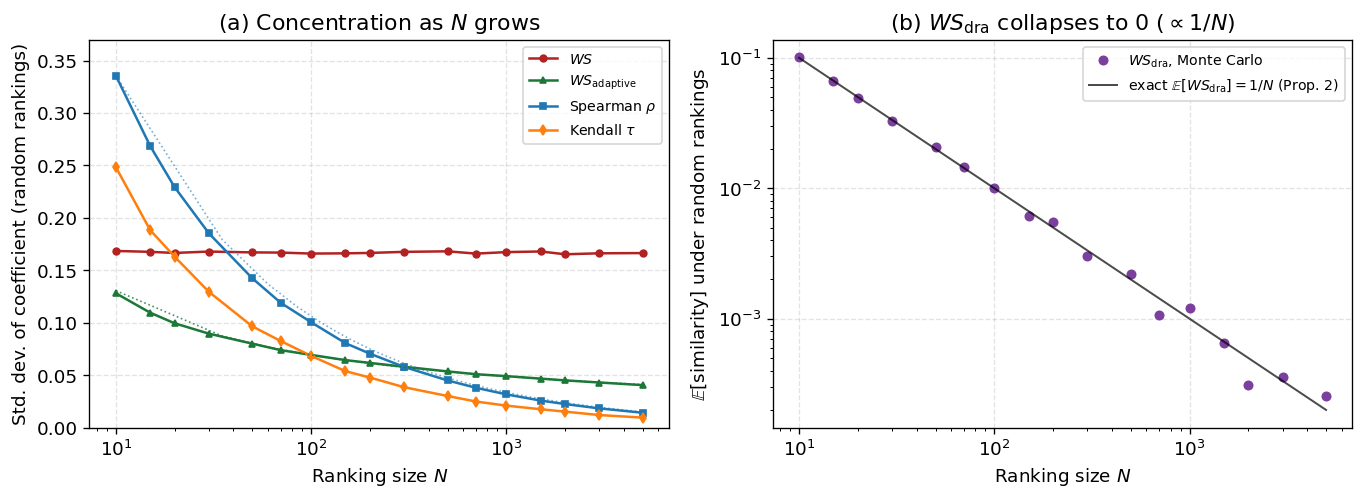

WS: log-log slope of std vs N (N>=100) = -0.000
WSa: log-log slope of std vs N (N>=100) = -0.136
rho: log-log slope of std vs N (N>=100) = -0.499
tau: log-log slope of std vs N (N>=100) = -0.502
std(WS_adaptive) vs 1/ln(N) linear fit: R^2 = 0.9993


In [15]:

N = rows_fine["N"].values.astype(float)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

ax = axes[0]
ax.plot(N, rows_fine["ws_std"], "o-", color=COLOR_WS, ms=4, label=r"$WS$")
ax.plot(N, rows_fine["wsa_std"], "^-", color=COLOR_ADAPT, ms=4, label=r"$WS_{\mathrm{adaptive}}$")
ax.plot(N, rows_fine["rho_std"], "s-", color=COLOR_RHO, ms=4, label=r"Spearman $\rho$")
ax.plot(N, rows_fine["tau_std"], "d-", color=COLOR_TAU, ms=4, label=r"Kendall $\tau$")
Nref = np.linspace(N.min(), N.max(), 200)
c_rho = rows_fine["rho_std"].iloc[0] * np.sqrt(N[0])
ax.plot(Nref, c_rho / np.sqrt(Nref), ":", color=COLOR_RHO, lw=1, alpha=0.6)
mask = N >= 50
c_ln, b_ln = np.polyfit(1.0 / np.log(N[mask]), rows_fine["wsa_std"][mask], 1)
ax.plot(Nref, c_ln / np.log(Nref) + b_ln, ":", color=COLOR_ADAPT, lw=1, alpha=0.8)
ax.set_xscale("log")
ax.set_xlabel(r"Ranking size $N$")
ax.set_ylabel(r"Std. dev. of coefficient (random rankings)")
ax.set_title("(a) Concentration as $N$ grows")
ax.legend(fontsize=8.5, loc="upper right")
ax.set_ylim(0, 0.37)

ax = axes[1]
ax.plot(N, rows_fine["wsdra_mean"], "o", color=COLOR_DRA, ms=5, label=r"$WS_{\mathrm{dra}}$, Monte Carlo")
ax.plot(Nref, 1.0 / Nref, "-", color="black", lw=1.2, alpha=0.7, label=r"exact $\mathbb{E}[WS_{\mathrm{dra}}]=1/N$ (Prop. 2)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"Ranking size $N$")
ax.set_ylabel(r"$\mathbb{E}[\text{similarity}]$ under random rankings")
ax.set_title(r"(b) $WS_{\mathrm{dra}}$ collapses to 0 ($\propto 1/N$)")
ax.legend(fontsize=8.5, loc="upper right")

fig.tight_layout()
fig.savefig(FIGDIR / "fig_concentration.pdf")
fig.savefig(FIGDIR / "fig_concentration.png", dpi=160)
plt.show()

mask = N >= 100
for name, col in [("WS", "ws_std"), ("WSa", "wsa_std"), ("rho", "rho_std"), ("tau", "tau_std")]:
    slope, _ = np.polyfit(np.log(N[mask]), np.log(rows_fine[col][mask]), 1)
    print(f"{name}: log-log slope of std vs N (N>=100) = {slope:.3f}")
mask2 = N >= 50
x = 1.0 / np.log(N[mask2]); y = rows_fine["wsa_std"][mask2]
slope2, intercept2 = np.polyfit(x, y, 1)
pred = slope2 * x + intercept2
r2 = 1 - np.sum((y - pred) ** 2) / np.sum((y - y.mean()) ** 2)
print(f"std(WS_adaptive) vs 1/ln(N) linear fit: R^2 = {r2:.4f}")


## 15. Practical usage guide (paper Table 4)

Because $\mu(N)=\mathbb{E}[WS_{\text{adaptive}}]$ and $\sigma(N)=\mathrm{Std}[WS_{\text{adaptive}}]$ both depend on $N$ (Section 14), a fixed rule of thumb is unsound. We calibrate a four-band reading directly from the Monte Carlo statistics computed above, at one representative $N$ per size regime (small $N\leq30$, medium $30<N\leq300$, large $N>300$):

- **Reversed**: $WS_{\text{adaptive}} < \mu(N)-\sigma(N)$
- **Different**: $[\mu(N)-\sigma(N),\ \mu(N)+\sigma(N))$ — chance level
- **Close**: $[\mu(N)+\sigma(N),\ 0.95)$ — clearly above chance
- **Identical**: $[0.95,\ 1]$ — a *fixed* absolute threshold (not $N$-dependent), since near-identity should not itself depend on the null calibration

This reproduces **Table 4** of the paper directly from the `rows_fine` statistics computed in Section 14 — no numbers are hand-typed.


In [16]:

def guide_row(N_repr, regime_label):
    row = rows_fine[rows_fine["N"] == N_repr].iloc[0]
    mu, sigma = row["wsa_mean"], row["wsa_std"]
    reversed_bound = mu - sigma
    close_start = mu + sigma
    return {
        "N regime": regime_label,
        "Reversed": f"< {reversed_bound:.2f}",
        "Different": f"[{reversed_bound:.2f}, {close_start:.2f})",
        "Close": f"[{close_start:.2f}, 0.95)",
        "Identical": "[0.95, 1]",
    }


table4 = pd.DataFrame([
    guide_row(10, "Small (N<=30, N=10)"),
    guide_row(100, "Medium (30<N<=300, N=100)"),
    guide_row(1000, "Large (N>300, N=1000)"),
]).set_index("N regime")
table4.to_csv(FIGDIR / "table4_practical_guide.csv")
table4


,Reversed,Different,Close,Identical
N regime,,,,
"Small (N<=30, N=10)",< 0.40,"[0.40, 0.65)","[0.65, 0.95)","[0.95, 1]"
"Medium (30<N<=300, N=100)",< 0.46,"[0.46, 0.60)","[0.60, 0.95)","[0.95, 1]"
"Large (N>300, N=1000)",< 0.48,"[0.48, 0.57)","[0.57, 0.95)","[0.95, 1]"


In [17]:

# Cross-check against the paper's worked examples (Section 4.3):
# full reversal at N=20,100,1000 should fall solidly in "Reversed";
# the N=1000, L=5% row of Table 2 (0.7138) should fall in "Close", not "Identical".
for N in [20, 100, 1000]:
    rx = np.arange(1, N + 1)
    v = ws_adaptive(rx, rx[::-1])
    print(f"N={N:5d}  WS_adaptive(full reversal) = {v:.4f}")

rx, ry, _ = l_percent_test(1000, 0.05, mode="invert")
v = ws_adaptive(rx, ry)
print(f"\nN=1000, L=5%% top-exact, tail reversed: WS_adaptive = {v:.4f}  (paper Table 2: 0.7138)")


N=   20  WS_adaptive(full reversal) = 0.2273
N=  100  WS_adaptive(full reversal) = 0.1828
N= 1000  WS_adaptive(full reversal) = 0.1326

N=1000, L=5%% top-exact, tail reversed: WS_adaptive = 0.7138  (paper Table 2: 0.7138)


## 16. Overall summary

**Part 1 (adversarial view, Sections 2-3 of the paper).** $WS$ saturates: the geometric weights $2^{-i}$ absorb $99.9\%$ of their mass by rank $\approx30$ regardless of $N$ (Theorem 1), so $WS\to1$ under any large-$N$ tail perturbation. $WS_{\text{adaptive}}$'s harmonic weights are saturation-free by construction (Proposition 1) while reproducing $WS$'s ranking order at small $N$ (Table 1).

**Part 2 (distributional view, Section 4 of the paper).** Under uniformly random rankings: $\mathbb{E}[WS]\to\tfrac12$ (Proposition 3, proven) and $\mathbb{E}[WS_{\text{adaptive}}]\to\tfrac12$ too, but only conjectured, and far more slowly ($O(1/\ln N)$); $\mathbb{E}[WS_{\text{dra}}\text{-similarity}]=1/N\to0$ exactly (Proposition 2, proven). Critically, $WS$'s standard deviation **never shrinks** with $N$ (frozen by Theorem 1) while $WS_{\text{adaptive}}$'s **does** shrink, slowly, like $\rho$ and $\tau$ — making $WS_{\text{adaptive}}$ the only coefficient studied that is simultaneously top-weighted (like $WS$) and non-degenerate at scale (like $\rho,\tau$).

**Reproducibility.** This notebook has no hidden state and no external data dependencies: running all cells top-to-bottom regenerates every number, table and figure in the paper from scratch (Python >= 3.9; `numpy`, `scipy`, `pandas`, `matplotlib`). All figures are written to `./figures/` as PDF (for LaTeX) and PNG (for quick viewing); all tables as CSV.

**Citation.** If you use this code, please cite the paper (see `main.tex` / the published version) and this repository.
